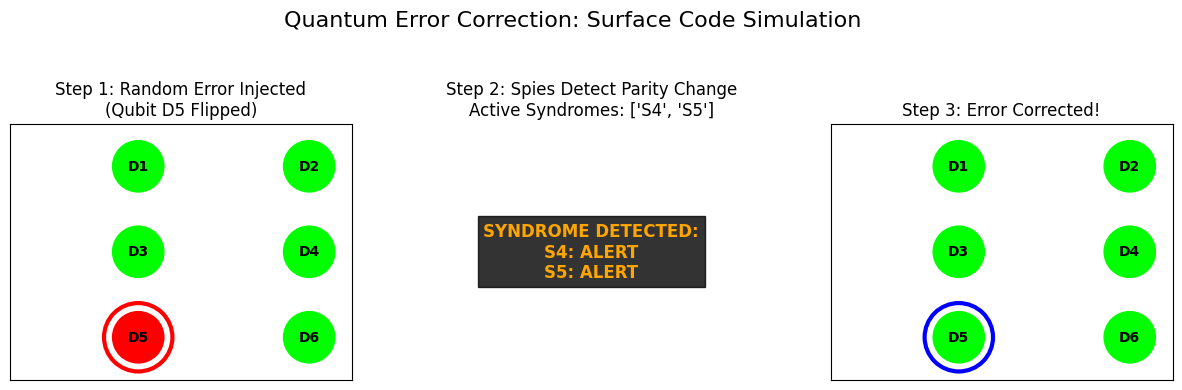

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==============================================================================
#  SURFACE CODE ERROR CORRECTION SIMULATION
#  Topology: Rotated Surface Code (Distance 3)
#  Physical Layer: Hex-SiGe Lattice
# ==============================================================================

# --- 1. DEFINE THE LATTICE ---
# We use a 5x5 grid.
# D = Data Qubit, S = Syndrome (Spy) Qubit, . = Empty
# Layout for Distance-3 Surface Code:
#   .  D1  .  D2  .
#   S1  .  S2  .  S3
#   .  D3  .  D4  .
#   S4  .  S5  .  S6
#   .  D5  .  D6  .

class SurfaceCodePatch:
    def __init__(self):
        # Initialize Data Qubits (Logic 0 = All Spin Up)
        # We track state as 0 (No Error) or 1 (Error/Flip)
        self.data_qubits = np.zeros(6, dtype=int) 
        
        # Map of which Data Qubits each Spy checks (Stabilizers)
        # (Indices correspond to D1...D6)
        self.stabilizers = {
            'S1': [0, 2],    # Checks D1, D3 (Z-Check)
            'S2': [0, 1, 2, 3], # Checks D1, D2, D3, D4 (X-Check)
            'S3': [1, 3],    # Checks D2, D4 (Z-Check)
            'S4': [2, 4],    # Checks D3, D5 (X-Check)
            'S5': [2, 3, 4, 5], # Checks D3, D4, D5, D6 (Z-Check)
            'S6': [3, 5]     # Checks D4, D6 (X-Check)
        }
        self.syndrome_history = {}

    def inject_random_error(self):
        # Randomly flip one data qubit (Simulating Cosmic Ray or Noise)
        target = np.random.randint(0, 6)
        self.data_qubits[target] = 1 # Flip!
        return target

    def measure_syndromes(self):
        # The Spies check their neighbors. 
        # If parity is odd (sum of neighbors % 2 == 1), the Spy lights up.
        syndrome = {}
        for name, neighbors in self.stabilizers.items():
            parity = sum(self.data_qubits[i] for i in neighbors) % 2
            syndrome[name] = parity
        return syndrome

    def correct_error(self, syndrome):
        # A simple "Lookup Table" Decoder.
        # In real life, this is a complex matching algorithm (MWPM).
        # We map specific spy patterns to the likely culprit.
        
        predicted_error = -1
        
        # LOGIC: Who triggers what?
        # Error on D1 -> Triggers S1, S2
        # Error on D2 -> Triggers S2, S3
        # Error on D3 -> Triggers S1, S2, S4, S5 (Center Left)
        # Error on D4 -> Triggers S2, S3, S5, S6 (Center Right)
        # Error on D5 -> Triggers S4, S5
        # Error on D6 -> Triggers S5, S6
        
        s = syndrome
        
        # Heuristic Matching (Simplified for demo)
        if s['S1'] and s['S2'] and not s['S3']: predicted_error = 0 # D1
        elif s['S2'] and s['S3'] and not s['S1']: predicted_error = 1 # D2
        elif s['S1'] and s['S2'] and s['S4'] and s['S5']: predicted_error = 2 # D3
        elif s['S2'] and s['S3'] and s['S5'] and s['S6']: predicted_error = 3 # D4
        elif s['S4'] and s['S5'] and not s['S6']: predicted_error = 4 # D5
        elif s['S5'] and s['S6'] and not s['S4']: predicted_error = 5 # D6
        
        # Apply Correction
        if predicted_error != -1:
            self.data_qubits[predicted_error] = 0 # Flip back
            return predicted_error, True
        return -1, False

# --- 2. RUN SIMULATION & VISUALIZE ---
chip = SurfaceCodePatch()

# A. State Before
before = chip.data_qubits.copy()

# B. Inject Error
error_loc = chip.inject_random_error()
after_error = chip.data_qubits.copy()

# C. Measure Spies
syndrome = chip.measure_syndromes()

# D. Correct
correction_loc, success = chip.correct_error(syndrome)
final = chip.data_qubits.copy()

# --- 3. PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Helper to draw grid
def draw_patch(ax, data, title, hl_qubit=None, hl_color='red'):
    # Create 3x4 grid for visualization
    grid = np.zeros((3, 4)) 
    # Map data vector to visual grid positions
    # D1(0,1), D2(0,3), D3(1,1), D4(1,3), D5(2,1), D6(2,3)
    coords = [(0,1), (0,3), (1,1), (1,3), (2,1), (2,3)]
    
    # Draw Background
    ax.imshow(np.zeros((3,4)), cmap='Greys', vmin=0, vmax=1)
    
    # Draw Qubits
    for i, (r, c) in enumerate(coords):
        color = 'lime' if data[i] == 0 else 'red' # Green=Good, Red=Error
        circle = plt.Circle((c, r), 0.3, color=color)
        ax.add_patch(circle)
        ax.text(c, r, f"D{i+1}", color='black', ha='center', va='center', fontweight='bold')
        
        # Highlight specific event
        if hl_qubit == i:
            ring = plt.Circle((c, r), 0.4, color=hl_color, fill=False, lw=3)
            ax.add_patch(ring)

    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Plot 1: The Error Event
draw_patch(axes[0], after_error, f"Step 1: Random Error Injected\n(Qubit D{error_loc+1} Flipped)", hl_qubit=error_loc)

# Plot 2: The Spy Network (Syndrome)
# Visualize which Stabilizers Lit Up
axes[1].imshow(np.zeros((3,4)), cmap='Greys')
axes[1].set_title(f"Step 2: Spies Detect Parity Change\nActive Syndromes: {[k for k,v in syndrome.items() if v]}")
# Hardcoded visual positions for Syndromes (Approximate)
s_coords = {'S1':(0,0), 'S2':(0,2), 'S3':(0,4), 'S4':(2,0), 'S5':(2,2), 'S6':(2,4)} # Visual shift
# Just text list for clarity
axes[1].text(1.5, 1, "SYNDROME DETECTED:\n" + "\n".join([f"{k}: ALERT" for k,v in syndrome.items() if v]), 
             ha='center', va='center', color='orange', fontweight='bold', fontsize=12, bbox=dict(facecolor='black', alpha=0.8))
axes[1].axis('off')

# Plot 3: The Correction
title = "Step 3: Error Corrected!" if success else "Step 3: Correction Failed"
draw_patch(axes[2], final, title, hl_qubit=correction_loc, hl_color='blue')

plt.suptitle("Quantum Error Correction: Surface Code Simulation", fontsize=16)
plt.show()